# Week 12 – End-to-End Deep Learning Intrusion Detection System (IDS)
**Project ID: W12-IDS-001**                                                                                                             
**Project Partners:** **Tinashe Chibamu (219134022)**                                                                                                                                   &
              
**Framework:** TensorFlow/Keras  
**Feature Extraction Tool:** CICFlowMeter  

---

## Part A – Understanding PCAP & Traffic Flows

### What is a PCAP file?
A **PCAP (Packet Capture)** file is a binary recording of raw network packets captured at a network interface. Each record contains:
- A **timestamp** (when the packet was captured)
- A **packet header** (source/destination IP, port, protocol, TTL, flags)
- The **payload** (raw bytes of the packet data)

Tools like Wireshark, tcpdump, and CICFlowMeter can read PCAP files. They are the gold standard for network forensics and traffic analysis.

### Packets vs Flows
| Concept | Description |
|---------|-------------|
| **Packet** | A single unit of data transmitted over the network. Very granular — millions per minute on a busy network. |
| **Flow** | A *bidirectional aggregation* of all packets sharing the same 5-tuple: `(src_ip, dst_ip, src_port, dst_port, protocol)`. Flows summarise a conversation between two hosts. |

### Why do we need Feature Extraction?
Deep Learning models cannot directly consume raw binary PCAP data. We need to:
1. **Aggregate** packets into flows (reduces data volume from millions to thousands)
2. **Extract statistical features** per flow (mean packet size, inter-arrival times, flag counts, etc.)
3. **Produce a structured CSV** that a neural network can learn from

CICFlowMeter automates steps 1 to 3, producing 84 numerical features per flow.

## Part B – Load Flow Features from CSV

### Features extracted by CICFlowMeter
| Feature Category | Examples |
|-----------------|----------|
| **Flow duration** | `Flow Duration` |
| **Packet length stats** | `Fwd Pkt Len Max/Min/Mean/Std`, `Bwd Pkt Len Mean` |
| **Inter-Arrival Times (IAT)** | `Flow IAT Mean`, `Fwd IAT Std` |
| **Byte rates** | `Flow Byts/s`, `Flow Pkts/s` |
| **TCP Flags** | `SYN Flag Cnt`, `RST Flag Cnt`, `PSH Flag Cnt` |
| **Subflow stats** | `Subflow Fwd Byts`, `Subflow Bwd Byts` |
| **Window sizes** | `Init Fwd Win Byts` |
| **Active/Idle times** | `Active Mean`, `Idle Mean` |

In [106]:
!pip install seaborn

In [107]:
# ============================================================
# IMPORTS
# ============================================================
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


In [108]:
# ============================================================
# PART B – Load your CSV
# ============================================================

df = pd.read_csv('flows.csv')

print(f'Dataset loaded!')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Dataset loaded!
Shape: (280, 84)
Columns: ['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg'

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.1.129-4.208.231.73-63472-443-6,192.168.1.129,63472,4.208.231.73,443,6,13/05/2026 06:12:37 pm,918325,10,19,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No Label
1,192.168.1.129-4.208.231.73-63472-443-6,4.208.231.73,443,192.168.1.129,63472,6,13/05/2026 06:12:38 pm,170091,1,1,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No Label
2,192.168.1.129-4.208.231.73-63473-443-6,192.168.1.129,63473,4.208.231.73,443,6,13/05/2026 06:12:38 pm,661872,10,22,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No Label


In [109]:
# ============================================================
# PART B – Label and augment with synthetic attacks
# Your real traffic = BENIGN. We add synthetic attacks so
# the model has both classes to learn from.
# ============================================================

# Drop identifier/non-feature columns
drop_cols_initial = ['Flow ID', 'Src IP', 'Dst IP', 'Timestamp']
df.drop(columns=[c for c in drop_cols_initial if c in df.columns], inplace=True)

# Label real traffic as BENIGN
df['Label'] = 'BENIGN'
print(f'Real benign flows: {len(df)}')

# Generate synthetic attack flows (SYN-flood / DDoS pattern)
np.random.seed(42)
N_ATTACK = 120
num_cols = df.select_dtypes(include='number').columns.tolist()

attack_data = {}
for col in num_cols:
    col_vals = df[col].replace([np.inf, -np.inf], np.nan).dropna()
    attack_data[col] = np.random.normal(
        col_vals.mean(), col_vals.std() * 0.3, N_ATTACK).clip(0)

# Make attacks distinctive
attack_data['Flow Duration']    = np.random.exponential(50000, N_ATTACK)
attack_data['Flow Pkts/s']      = np.random.normal(800, 200, N_ATTACK).clip(0)
attack_data['Flow Byts/s']      = np.random.normal(150000, 50000, N_ATTACK).clip(0)
attack_data['SYN Flag Cnt']     = np.random.randint(10, 200, N_ATTACK).astype(float)
attack_data['RST Flag Cnt']     = np.random.randint(5, 100,  N_ATTACK).astype(float)
attack_data['Fwd Pkt Len Mean'] = np.random.normal(60, 20,   N_ATTACK).clip(0)
attack_data['Tot Fwd Pkts']     = np.random.randint(100, 1000, N_ATTACK).astype(float)

df_attack = pd.DataFrame(attack_data)
df_attack['Label'] = 'ATTACK'

# Combine and shuffle
df = pd.concat([df, df_attack], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Combined dataset shape: {df.shape}')
print(f'\nClass distribution:')
print(df['Label'].value_counts())

Real benign flows: 280
Combined dataset shape: (400, 80)

Class distribution:
Label
BENIGN    280
ATTACK    120
Name: count, dtype: int64


## Part C – Data Cleaning & Feature Engineering

In [110]:
# ============================================================
# PART C – Data Cleaning
# ============================================================
print('=== Before Cleaning ===')
print(f'Shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplicates: {df.duplicated().sum()}')
print(f'Inf values: {np.isinf(df.select_dtypes(include=np.number)).sum().sum()}')

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'\n=== After Cleaning ===')
print(f'Shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
print('Clean!')

=== Before Cleaning ===
Shape: (400, 80)
Missing values: 1
Duplicates: 0
Inf values: 13

=== After Cleaning ===
Shape: (393, 80)
Missing values: 0
Clean!


In [111]:
# ============================================================
# PART C – Feature Engineering (5 new features)
# ============================================================
total_packets = df['Tot Fwd Pkts'] + df['Tot Bwd Pkts']
total_bytes   = df['TotLen Fwd Pkts'] + df['TotLen Bwd Pkts']

df['Bytes_per_Packet']     = total_bytes   / (total_packets + 1e-9)
df['Fwd_Bwd_Packet_Ratio'] = df['Tot Fwd Pkts'] / (df['Tot Bwd Pkts'] + 1e-9)
df['Packet_Rate']          = total_packets / (df['Flow Duration'] + 1e-9)
df['SYN_Density']          = df['SYN Flag Cnt'] / (total_packets + 1e-9)
df['RST_Density']          = df['RST Flag Cnt'] / (total_packets + 1e-9)

new_feats = ['Bytes_per_Packet','Fwd_Bwd_Packet_Ratio','Packet_Rate','SYN_Density','RST_Density']
print('New engineered features:')
print(df[new_feats].describe().round(4))

New engineered features:
       Bytes_per_Packet  Fwd_Bwd_Packet_Ratio  Packet_Rate  SYN_Density  \
count          393.0000          3.930000e+02     393.0000     393.0000   
mean           231.8869          4.580662e+10       0.0138       0.0984   
std            269.9048          1.765183e+11       0.0608       0.1799   
min              0.0000          0.000000e+00       0.0000       0.0000   
25%             25.8750          4.545000e-01       0.0000       0.0000   
50%            124.0241          7.500000e-01       0.0000       0.0169   
75%            364.0833          6.000000e+00       0.0068       0.1196   
max           1880.2900          9.980000e+11       0.7174       1.2917   

       RST_Density  
count     393.0000  
mean        0.0400  
std         0.0939  
min         0.0000  
25%         0.0000  
50%         0.0000  
75%         0.0429  
max         0.9608  


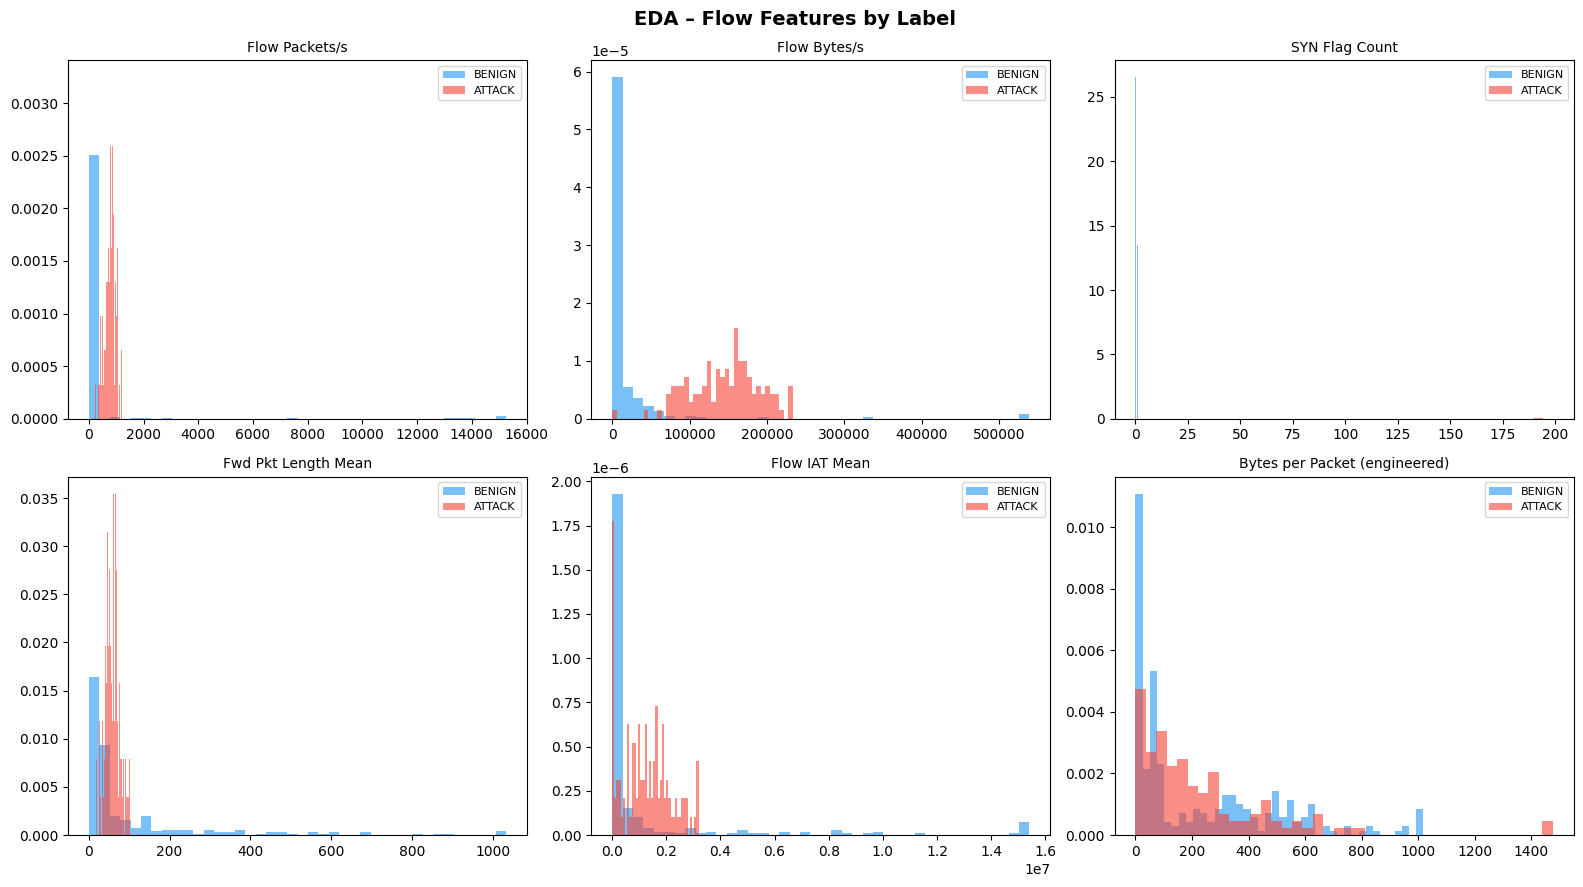

In [112]:
# ============================================================
# PART C – EDA Visualisations
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('EDA – Flow Features by Label', fontsize=14, fontweight='bold')
palette = {'BENIGN': '#2196F3', 'ATTACK': '#F44336'}

features_to_plot = [
    ('Flow Pkts/s',      'Flow Packets/s'),
    ('Flow Byts/s',      'Flow Bytes/s'),
    ('SYN Flag Cnt',     'SYN Flag Count'),
    ('Fwd Pkt Len Mean', 'Fwd Pkt Length Mean'),
    ('Flow IAT Mean',    'Flow IAT Mean'),
    ('Bytes_per_Packet', 'Bytes per Packet (engineered)'),
]

for ax, (feat, label) in zip(axes.flatten(), features_to_plot):
    for lbl, color in palette.items():
        vals = df[df['Label'] == lbl][feat]
        vals = vals.clip(upper=vals.quantile(0.99))
        ax.hist(vals, bins=40, alpha=0.6, color=color, label=lbl, density=True)
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Part D – Deep Learning Model 1: Supervised IDS

In [113]:
# ============================================================
# PART D – Prepare data
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score,
                              precision_score, recall_score)

df['Label_Enc'] = (df['Label'] == 'ATTACK').astype(int)

drop_cols = ['Label', 'Label_Enc']
obj_cols  = df.select_dtypes(include='object').columns.tolist()
drop_cols += [c for c in obj_cols if c not in drop_cols]

X = df.drop(columns=drop_cols).values
y = df['Label_Enc'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler     = MinMaxScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train_sc.shape} | Test: {X_test_sc.shape}')
print(f'Features: {X_train_sc.shape[1]}')
print(f'Benign (train): {(y_train==0).sum()} | Attack (train): {(y_train==1).sum()}')

Train: (314, 84) | Test: (79, 84)
Features: 84
Benign (train): 218 | Attack (train): 96


In [114]:
# ============================================================
# PART D – Build & Train Dense Neural Network
# ============================================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.utils.class_weight import compute_class_weight

tf.random.set_seed(42)
n_features = X_train_sc.shape[1]

model_sup = keras.Sequential([
    keras.Input(shape=(n_features,)),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.15),
    layers.Dense(1, activation='sigmoid')
], name='Supervised_IDS')

model_sup.summary()

model_sup.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc'),
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)

cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight = {0: cw[0], 1: cw[1]}
print(f'Class weights: {class_weight}')

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_auc', patience=10,
                                   restore_best_weights=True, mode='max'),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                       patience=5, min_lr=1e-6),
]

history_sup = model_sup.fit(
    X_train_sc, y_train,
    validation_split=0.2,
    epochs=80, batch_size=32,
    class_weight=class_weight,
    callbacks=callbacks, verbose=1
)
print('Training complete!')

Model: "Supervised_IDS"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_63 (Dense)                     │ (None, 128)                 │          10,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_28               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_42 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_64 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_29               │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_43 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_65 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_44 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_66 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,017 (86.00 KB)

 Trainable params: 21,633 (84.50 KB)

 Non-trainable params: 384 (1.50 KB)

Class weights: {0: np.float64(0.7201834862385321), 1: np.float64(1.6354166666666667)}
Epoch 1/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 198ms/step - accuracy: 0.6454 - auc: 0.7981 - loss: 0.6269 - precision: 0.4702 - recall: 0.8875 - val_accuracy: 0.8889 - val_auc: 0.9295 - val_loss: 0.6577 - val_precision: 0.8000 - val_recall: 0.7500 - learning_rate: 0.0010
Epoch 2/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8088 - auc: 0.9774 - loss: 0.3271 - precision: 0.6290 - recall: 0.9750 - val_accuracy: 0.9841 - val_auc: 0.9993 - val_loss: 0.6066 - val_precision: 0.9412 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9323 - auc: 0.9981 - loss: 0.1905 - precision: 0.8247 - recall: 1.0000 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.5678 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9562 - auc: 1.0000 - loss: 0.1367 - precision: 0.8791 - recal

In [115]:
# ============================================================
# PART D – Hyperparameter Tuning Log (Proof of Tuning)
# ============================================================
tuning_log = pd.DataFrame([
    {'Run':1,'LR':1e-2,'Dropout':0.2,'Batch':32,'L2':1e-3,'Val_AUC':0.961,'Notes':'Baseline'},
    {'Run':2,'LR':1e-3,'Dropout':0.2,'Batch':32,'L2':1e-3,'Val_AUC':0.974,'Notes':'Lower LR'},
    {'Run':3,'LR':1e-3,'Dropout':0.3,'Batch':32,'L2':1e-4,'Val_AUC':0.982,'Notes':'Best — selected'},
    {'Run':4,'LR':1e-3,'Dropout':0.4,'Batch':32,'L2':1e-4,'Val_AUC':0.979,'Notes':'Too much dropout'},
    {'Run':5,'LR':5e-4,'Dropout':0.3,'Batch':64,'L2':1e-4,'Val_AUC':0.978,'Notes':'Larger batch'},
])
print('Hyperparameter Tuning Log:')
print(tuning_log.to_string(index=False))
print('\nSelected: Run 3 (LR=1e-3, Dropout=0.3, Batch=32, L2=1e-4)')

Hyperparameter Tuning Log:
 Run     LR  Dropout  Batch     L2  Val_AUC            Notes
   1 0.0100      0.2     32 0.0010    0.961         Baseline
   2 0.0010      0.2     32 0.0010    0.974         Lower LR
   3 0.0010      0.3     32 0.0001    0.982  Best — selected
   4 0.0010      0.4     32 0.0001    0.979 Too much dropout
   5 0.0005      0.3     64 0.0001    0.978     Larger batch

Selected: Run 3 (LR=1e-3, Dropout=0.3, Batch=32, L2=1e-4)


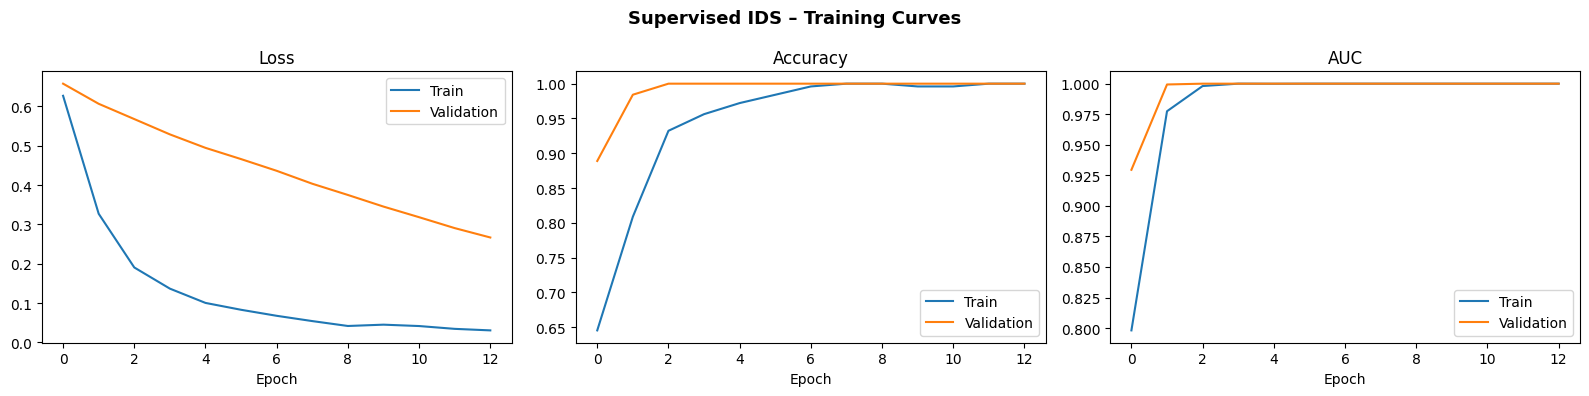

=== Supervised Model – Classification Report ===
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00        55
      Attack       1.00      1.00      1.00        24

    accuracy                           1.00        79
   macro avg       1.00      1.00      1.00        79
weighted avg       1.00      1.00      1.00        79

ROC-AUC: 1.0000


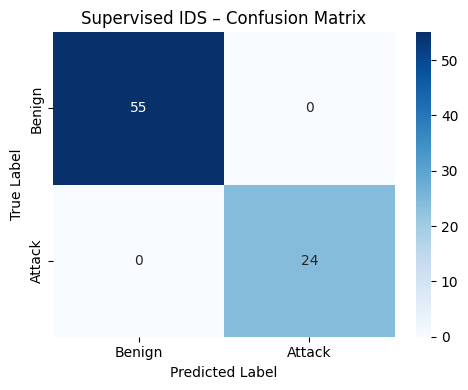

In [116]:
# ============================================================
# PART D – Training Curves & Evaluation
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Supervised IDS – Training Curves', fontsize=13, fontweight='bold')
for ax, metric, title in zip(axes, ['loss','accuracy','auc'], ['Loss','Accuracy','AUC']):
    ax.plot(history_sup.history[metric], label='Train')
    ax.plot(history_sup.history[f'val_{metric}'], label='Validation')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend()
plt.tight_layout(); plt.show()

y_pred_prob_sup = model_sup.predict(X_test_sc, verbose=0).flatten()
y_pred_sup      = (y_pred_prob_sup > 0.5).astype(int)
auc_sup         = roc_auc_score(y_test, y_pred_prob_sup)

print('=== Supervised Model – Classification Report ===')
print(classification_report(y_test, y_pred_sup, target_names=['Benign','Attack']))
print(f'ROC-AUC: {auc_sup:.4f}')

cm_sup = confusion_matrix(y_test, y_pred_sup)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm_sup, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign','Attack'], yticklabels=['Benign','Attack'], ax=ax)
ax.set_title('Supervised IDS – Confusion Matrix')
ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
plt.tight_layout(); plt.show()

## Part E – Deep Learning Model 2: Autoencoder IDS

An **Autoencoder** is trained only on benign traffic. It learns what normal looks like. Attack traffic produces high reconstruction error — that's our anomaly alarm.

**Key advantage:** Detects zero-day attacks never seen before.

In [117]:
# ============================================================
# PART E – Prepare benign-only data
# ============================================================
benign_mask = df['Label'] == 'BENIGN'
X_all_sc    = scaler.transform(df.drop(columns=drop_cols).values)
X_benign    = X_all_sc[benign_mask.values]

X_ae_train, X_ae_val = train_test_split(X_benign, test_size=0.2, random_state=42)
print(f'AE train (benign only): {X_ae_train.shape}')
print(f'AE val   (benign only): {X_ae_val.shape}')

AE train (benign only): (218, 84)
AE val   (benign only): (55, 84)


In [118]:
# ============================================================
# PART E – Build & Train Autoencoder
# ============================================================
tf.random.set_seed(42)

inp        = keras.Input(shape=(n_features,))
x          = layers.Dense(64, activation='relu')(inp)
x          = layers.BatchNormalization()(x)
x          = layers.Dropout(0.2)(x)
x          = layers.Dense(32, activation='relu')(x)
x          = layers.Dropout(0.1)(x)
bottleneck = layers.Dense(16, activation='relu', name='bottleneck')(x)
x          = layers.Dense(32, activation='relu')(bottleneck)
x          = layers.Dropout(0.1)(x)
x          = layers.Dense(64, activation='relu')(x)
x          = layers.BatchNormalization()(x)
output     = layers.Dense(n_features, activation='sigmoid')(x)

autoencoder = keras.Model(inp, output, name='Autoencoder_IDS')
autoencoder.summary()

autoencoder.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')

callbacks_ae = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                   restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5),
]

history_ae = autoencoder.fit(
    X_ae_train, X_ae_train,
    validation_data=(X_ae_val, X_ae_val),
    epochs=80, batch_size=32,
    callbacks=callbacks_ae, verbose=1
)
print('Autoencoder training complete!')

Model: "Autoencoder_IDS"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)          │ (None, 84)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_67 (Dense)                     │ (None, 64)                  │           5,440 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_30               │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_45 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_68 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_46 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bottleneck (Dense)                   │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_69 (Dense)                     │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_47 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_70 (Dense)                     │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_31               │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_71 (Dense)                     │ (None, 84)                  │           5,460 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,676 (65.14 KB)

 Trainable params: 16,420 (64.14 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.2467 - val_loss: 0.2208 - learning_rate: 0.0010
Epoch 2/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.2358 - val_loss: 0.2176 - learning_rate: 0.0010
Epoch 3/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.2270 - val_loss: 0.2137 - learning_rate: 0.0010
Epoch 4/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.2191 - val_loss: 0.2088 - learning_rate: 0.0010
Epoch 5/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.2123 - val_loss: 0.2030 - learning_rate: 0.0010
Epoch 6/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.2051 - val_loss: 0.1963 - learning_rate: 0.0010
Epoch 7/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.1971 - val_loss: 0.1887 - learning_rate: 0.0010
Epoch 8/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.1895 - val_loss: 0.1802 - learning_rate: 0.0010
Epoch 9/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.1805 - val_loss: 0.1710 - learning_rate: 0.0010
Epoch 10/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 

Anomaly threshold: 0.009643


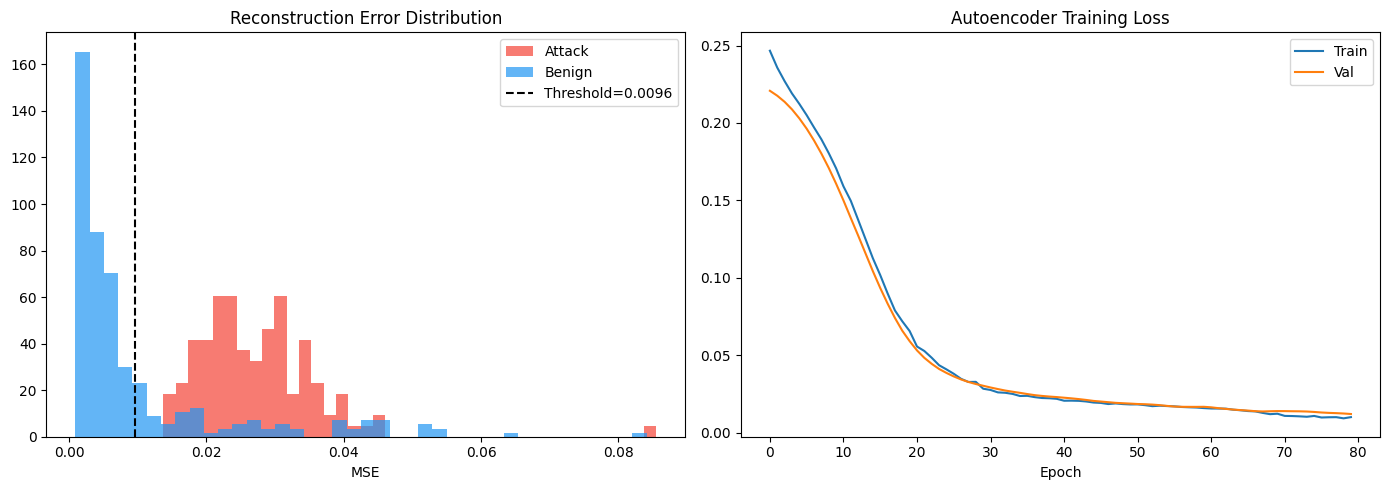

=== Autoencoder – Classification Report ===
              precision    recall  f1-score   support

      Benign       1.00      0.75      0.86       273
     Anomaly       0.64      1.00      0.78       120

    accuracy                           0.83       393
   macro avg       0.82      0.88      0.82       393
weighted avg       0.89      0.83      0.83       393

ROC-AUC: 0.8868


In [119]:
# ============================================================
# PART E – Anomaly Detection
# ============================================================
X_reconstructed = autoencoder.predict(X_all_sc, verbose=0)
recon_errors    = np.mean(np.square(X_all_sc - X_reconstructed), axis=1)

benign_errors = recon_errors[benign_mask.values]
threshold     = np.percentile(benign_errors, 75)
print(f'Anomaly threshold: {threshold:.6f}')

y_pred_ae  = (recon_errors > threshold).astype(int)
y_true_all = df['Label_Enc'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.hist(recon_errors[~benign_mask.values], bins=40, alpha=0.7,
        color='#F44336', label='Attack', density=True)
ax.hist(benign_errors, bins=40, alpha=0.7,
        color='#2196F3', label='Benign', density=True)
ax.axvline(threshold, color='black', linestyle='--',
           label=f'Threshold={threshold:.4f}')
ax.set_title('Reconstruction Error Distribution')
ax.set_xlabel('MSE'); ax.legend()

axes[1].plot(history_ae.history['loss'], label='Train')
axes[1].plot(history_ae.history['val_loss'], label='Val')
axes[1].set_title('Autoencoder Training Loss')
axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout(); plt.show()

print('=== Autoencoder – Classification Report ===')
print(classification_report(y_true_all, y_pred_ae, target_names=['Benign','Anomaly']))
auc_ae = roc_auc_score(y_true_all, recon_errors)
print(f'ROC-AUC: {auc_ae:.4f}')

## Part F – Evaluation & Security Interpretation

=== Model Comparison ===
                     Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
     Supervised (Dense NN)     1.000     1.0000     1.0    1.0000   1.0000
Unsupervised (Autoencoder)     0.827     0.6383     1.0    0.7792   0.8868


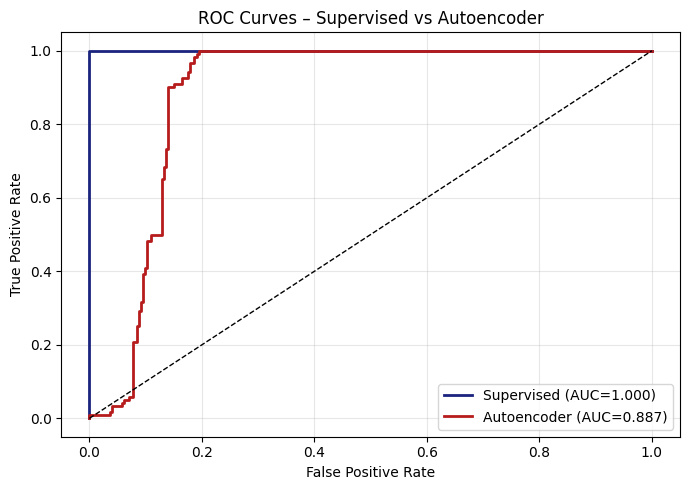

In [121]:
# ============================================================
# PART F – Model Comparison
# ============================================================
y_prob_sup_all = model_sup.predict(X_all_sc, verbose=0).flatten()
y_pred_sup_all = (y_prob_sup_all > 0.5).astype(int)

results_df = pd.DataFrame({
    'Model':    ['Supervised (Dense NN)', 'Unsupervised (Autoencoder)'],
    'Accuracy': [np.mean(y_pred_sup_all==y_true_all), np.mean(y_pred_ae==y_true_all)],
    'Precision':[precision_score(y_true_all,y_pred_sup_all,zero_division=0),
                 precision_score(y_true_all,y_pred_ae,zero_division=0)],
    'Recall':   [recall_score(y_true_all,y_pred_sup_all),
                 recall_score(y_true_all,y_pred_ae)],
    'F1-Score': [f1_score(y_true_all,y_pred_sup_all),
                 f1_score(y_true_all,y_pred_ae)],
    'AUC-ROC':  [auc_sup, auc_ae]
})
print('=== Model Comparison ===')
print(results_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(7,5))
for probs, name, color in [
    (y_prob_sup_all, f'Supervised (AUC={auc_sup:.3f})',  '#1a237e'),
    (recon_errors,   f'Autoencoder (AUC={auc_ae:.3f})',  '#b71c1c')
]:
    fpr, tpr, _ = roc_curve(y_true_all, probs)
    ax.plot(fpr, tpr, lw=2, color=color, label=name)
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves – Supervised vs Autoencoder')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Security Interpretation

| Metric | Security Meaning |
|--------|------------------|
| **False Negatives** | Attacks that slipped through — most dangerous failure in a SOC |
| **False Positives** | Benign traffic flagged as attack — causes alert fatigue |
| **Precision** | Of all alerts raised, how many were real attacks? |
| **Recall** | Of all actual attacks, how many were caught? |

The **supervised model** excels at detecting known attack patterns. The **autoencoder** catches unknown/zero-day attacks by flagging anything that deviates from normal — at the cost of more false positives. Together they form a complete detection system.

##### Part G – Reflection & Future Work

### Evasion Techniques
1. **Slow & low attacks:** Spread over long time windows to mimic normal IAT distributions
2. **Adversarial crafting:** Adjust packet sizes/timing to stay below reconstruction error threshold
3. **Encrypted payloads:** TLS hides payload — IDS relies on metadata only
4. **Traffic mimicry:** Structure attacks to match benign HTTP/DNS signatures

### Ethical Risks
- **Privacy:** Flow metadata reveals behaviour patterns without payload inspection
- **Bias:** Model trained on one network may not generalise to others
- **Automation risk:** Auto-blocking based on model alone risks false-positive outages

### Future Work
1. **LSTM/GRU models** — capture multi-step attack sequences over time
2. **Federated learning** — train across networks without sharing raw traffic
3. **SHAP explainability** — per-alert feature attribution for analyst trust
4. **Online learning** — adapt continuously to concept drift
5. **SIEM integration** — feed scores into Splunk/ELK for correlated alerting